Dataset Loaded: (20, 7)

Thresholds:
Avg Cost: 417.9157177999999
Avg Defect: 6.2234336608
Avg Efficiency: 0.006801468029433271

Segment Distribution:
segment
Top Performer        6
High Risk            5
Premium Supplier     4
Low Cost Risky       3
Average Performer    2
Name: count, dtype: int64


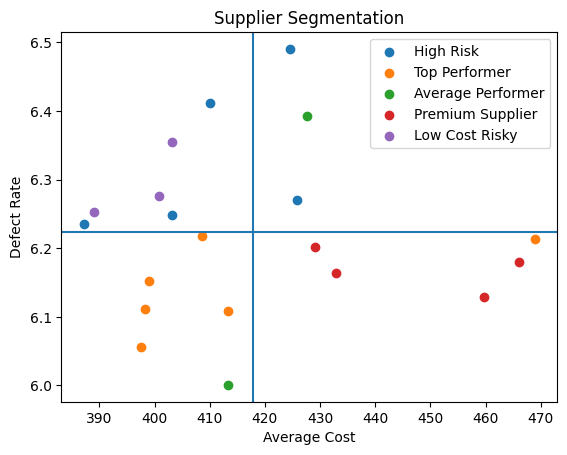


Day 15 Segmentation Completed Successfully


In [1]:
# Day 15 - Supplier Segmentation Analysis
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------------------------------------
# PATH SETUP
# ----------------------------------------------------------

PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/vendor_efficiency.csv"

OUTPUT_DIR = PROJECT_ROOT / "03_processed_data"
VIS_DIR = PROJECT_ROOT / "04_visualizations"

OUTPUT_DIR.mkdir(exist_ok=True)
VIS_DIR.mkdir(exist_ok=True)

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------

df = pd.read_csv(INPUT_FILE)

print("Dataset Loaded:", df.shape)

# ----------------------------------------------------------
# 1. THRESHOLDS (IMPORTANT)
# ----------------------------------------------------------

avg_cost = df["avg_cost"].mean()
avg_defect = df["avg_defect"].mean()
avg_eff = df["efficiency"].mean()

print("\nThresholds:")
print("Avg Cost:", avg_cost)
print("Avg Defect:", avg_defect)
print("Avg Efficiency:", avg_eff)

# ----------------------------------------------------------
# 2. SEGMENT CLASSIFICATION
# ----------------------------------------------------------

def classify(row):
    if row["avg_defect"] > avg_defect and row["efficiency"] < avg_eff:
        return "High Risk"

    elif row["avg_defect"] < avg_defect and row["efficiency"] > avg_eff:
        return "Top Performer"

    elif row["avg_cost"] > avg_cost and row["avg_defect"] < avg_defect:
        return "Premium Supplier"

    elif row["avg_cost"] < avg_cost and row["avg_defect"] > avg_defect:
        return "Low Cost Risky"

    else:
        return "Average Performer"


df["segment"] = df.apply(classify, axis=1)

# ----------------------------------------------------------
# 3. SEGMENT DISTRIBUTION
# ----------------------------------------------------------

segment_counts = df["segment"].value_counts()

print("\nSegment Distribution:")
print(segment_counts)

segment_counts.to_csv(
    OUTPUT_DIR / "segment_summary.csv"
)

# ----------------------------------------------------------
# 4. SAVE SEGMENTED DATASET
# ----------------------------------------------------------

df.to_csv(
    OUTPUT_DIR / "vendor_segmentation.csv",
    index=False
)

# ----------------------------------------------------------
# 5. VISUALIZATION (SCATTER WITH SEGMENTS)
# ----------------------------------------------------------

plt.figure()

for segment in df["segment"].unique():
    subset = df[df["segment"] == segment]

    plt.scatter(
        subset["avg_cost"],
        subset["avg_defect"],
        label=segment
    )

# Threshold lines
plt.axhline(avg_defect)
plt.axvline(avg_cost)

plt.xlabel("Average Cost")
plt.ylabel("Defect Rate")
plt.title("Supplier Segmentation")

plt.legend()

plt.savefig(
    VIS_DIR / "supplier_segmentation.png"
)
plt.show()
plt.close()

# ----------------------------------------------------------
# 6. TOP PERFORMERS LIST
# ----------------------------------------------------------

top_performers = df[df["segment"] == "Top Performer"]

top_performers.to_csv(
    OUTPUT_DIR / "top_performers.csv",
    index=False
)

# ----------------------------------------------------------
# 7. HIGH RISK VENDORS LIST
# ----------------------------------------------------------

high_risk = df[df["segment"] == "High Risk"]

high_risk.to_csv(
    OUTPUT_DIR / "high_risk_vendors.csv",
    index=False
)

# ----------------------------------------------------------
# 8. FINAL STATUS
# ----------------------------------------------------------

print("\nDay 15 Segmentation Completed Successfully")